<a href="https://colab.research.google.com/github/ArkanUbaidillah/Arkan-Ubaidillah-Warman_2411537001_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [2]:
dataset_url = 'https://raw.githubusercontent.com/ArkanUbaidillah/Arkan-Ubaidillah-Warman_2411537001_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data_cae7db121c99c2dfb709598afde3ccfe.csv'
data = pd.read_csv(dataset_url)
data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
model_no_scaling = LogisticRegression(max_iter=10000)

model_no_scaling.fit(X_train, y_train)

y_pred_ns = model_no_scaling.predict(X_test)
y_prob_ns = model_no_scaling.predict_proba(X_test)[:,1]

In [23]:
print("TANPA SCALING")

print("Accuracy :", accuracy_score(y_test, y_pred_ns))
print("Precision:", precision_score(y_test, y_pred_ns))
print("Recall   :", recall_score(y_test, y_pred_ns))
print("F1 Score :", f1_score(y_test, y_pred_ns))
print("AUC      :", roc_auc_score(y_test, y_prob_ns))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_ns))

TANPA SCALING
Accuracy : 0.9298245614035088
Precision: 0.9565217391304348
Recall   : 0.9295774647887324
F1 Score : 0.9428571428571428
AUC      : 0.9882083196855552
Confusion Matrix
[[40  3]
 [ 5 66]]


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model_scaling = LogisticRegression(max_iter=10000)

model_scaling.fit(X_train_scaled, y_train)

y_pred_s = model_scaling.predict(X_test_scaled)
y_prob_s = model_scaling.predict_proba(X_test_scaled)[:,1]

In [15]:
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred_s, target_names=target_names) )

                  precision    recall  f1-score   support

without diabetes       0.93      0.91      0.92        43
   with diabetes       0.94      0.96      0.95        71

        accuracy                           0.94       114
       macro avg       0.94      0.93      0.93       114
    weighted avg       0.94      0.94      0.94       114



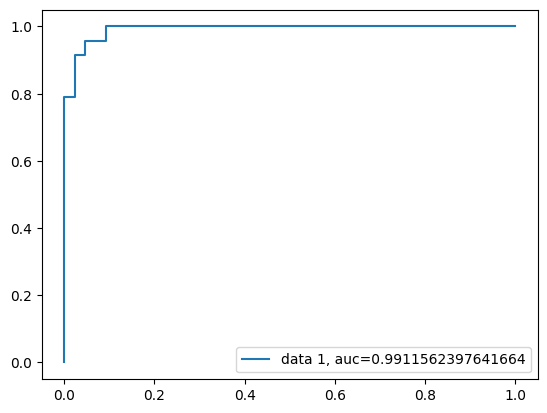

In [17]:
y_pred_proba = model_scaling.predict_proba(X_test_scaled) [ :: ,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr, label="data 1, auc="+str(auc))
plt. legend(loc=4)
plt.show()

In [19]:
thresholds = [0.3,0.4,0.5,0.6,0.7]
print("Threshold Analysis\n")
for t in thresholds:

    y_pred_t = (y_prob_s >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    print("Threshold:", t)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print()

Threshold Analysis

Threshold: 0.3
Accuracy : 0.9473684210526315
Precision: 0.922077922077922
Recall   : 1.0
F1 Score : 0.9594594594594594

Threshold: 0.4
Accuracy : 0.9649122807017544
Precision: 0.9466666666666667
Recall   : 1.0
F1 Score : 0.9726027397260274

Threshold: 0.5
Accuracy : 0.9385964912280702
Precision: 0.9444444444444444
Recall   : 0.9577464788732394
F1 Score : 0.951048951048951

Threshold: 0.6
Accuracy : 0.9385964912280702
Precision: 0.9705882352941176
Recall   : 0.9295774647887324
F1 Score : 0.9496402877697842

Threshold: 0.7
Accuracy : 0.9298245614035088
Precision: 0.9846153846153847
Recall   : 0.9014084507042254
F1 Score : 0.9411764705882353



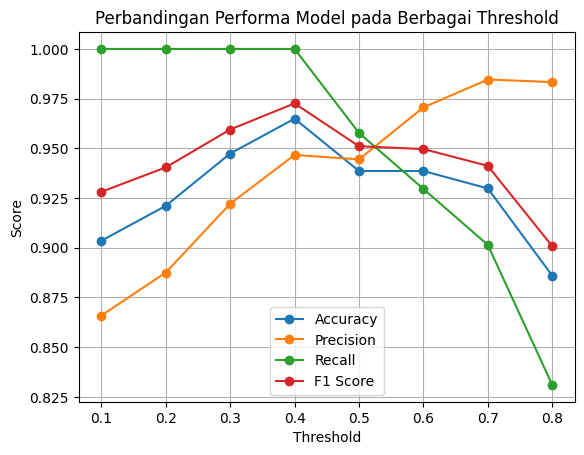

In [25]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.1)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for t in thresholds:

    y_pred_t = (y_prob_s >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)

plt.figure()

plt.plot(thresholds, accuracy_list, marker='o', label='Accuracy')
plt.plot(thresholds, precision_list, marker='o', label='Precision')
plt.plot(thresholds, recall_list, marker='o', label='Recall')
plt.plot(thresholds, f1_list, marker='o', label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Perbandingan Performa Model pada Berbagai Threshold")
plt.legend()
plt.grid(True)

plt.show()

Text(0.5, 427.9555555555555, 'Predicted label')

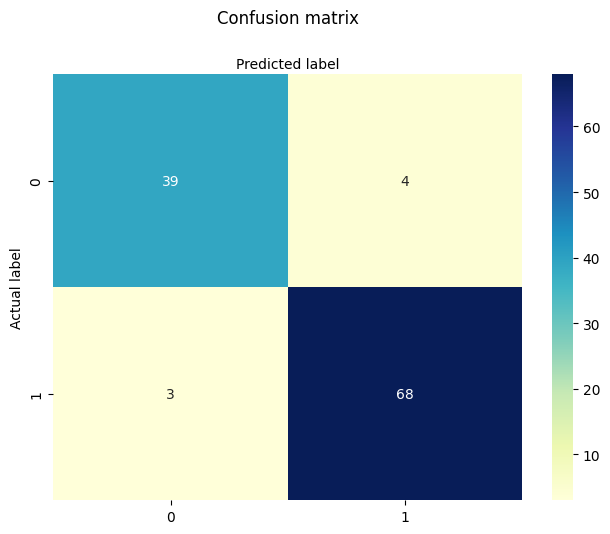

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cnf_matrix = confusion_matrix(y_test, y_pred_s)

class_names=[0,1] # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" , fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')